In [2]:
import pandas as pd 
import numpy as np

In [3]:
df=pd.read_csv(r"C:\Users\abdul\Documents\BIA\ML\Dataset\train_LZdllcl.csv")
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
print(df.isnull().sum())

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64


In [5]:
TARGET="is_promoted"

In [6]:
cat_cols=df.select_dtypes(include="str").columns.tolist()
print(cat_cols)

['department', 'region', 'education', 'gender', 'recruitment_channel']


In [7]:
cat_cols=df.select_dtypes(include="str").columns.tolist()
num_cols=df.select_dtypes(include=np.number).columns.drop(TARGET).tolist()
print("Categorical:",cat_cols)
print("Numerical:",num_cols)
#streamlit

Categorical: ['department', 'region', 'education', 'gender', 'recruitment_channel']
Numerical: ['employee_id', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score']


In [8]:
for col in num_cols:
    df[col]=df[col].fillna(df[col].mean())
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])
print("missing after imputation:",df.isna().sum())

missing after imputation: employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64


In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit_transform(df["gender"])

array([0, 1, 1, ..., 1, 1, 1], shape=(54808,))

In [10]:
df = pd.get_dummies(
    df,
    columns=["gender"],
    dtype=int
)

df.head()

,employee_id,department,region,education,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,gender_f,gender_m
0,65438,Sales & Marketing,region_7,Master's & above,sourcing,1,35,5.0,8,1,0,49,0,1,0
1,65141,Operations,region_22,Bachelor's,other,1,30,5.0,4,0,0,60,0,0,1
2,7513,Sales & Marketing,region_19,Bachelor's,sourcing,1,34,3.0,7,0,0,50,0,0,1
3,2542,Sales & Marketing,region_23,Bachelor's,other,2,39,1.0,10,0,0,50,0,0,1
4,48945,Technology,region_26,Bachelor's,other,1,45,3.0,2,0,0,73,0,0,1


In [11]:
print(df.isnull().sum())

employee_id             0
department              0
region                  0
education               0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
gender_f                0
gender_m                0
dtype: int64


In [14]:
yes_no_cols =['gender_f']
for col in yes_no_cols:
    df[col]=df[col].map({"yes":1,"no":0})
df["gender_f"]=df["gender_f"].map({
    "Sales & Marketing":1,
    "Operations":2,
    "Technology":3,
})
df.head()

,employee_id,department,region,education,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,gender_f,gender_m
0,65438,NaN,NaN,NaN,sourcing,1,35,5.0,8,1,0,49,0,NaN,0
1,65141,NaN,NaN,NaN,other,1,30,5.0,4,0,0,60,0,NaN,1
2,7513,NaN,NaN,NaN,sourcing,1,34,3.0,7,0,0,50,0,NaN,1
3,2542,NaN,NaN,NaN,other,2,39,1.0,10,0,0,50,0,NaN,1
4,48945,NaN,NaN,NaN,other,1,45,3.0,2,0,0,73,0,NaN,1


In [ ]:
print(df["department"].unique())
print(df["region"].unique())
print(df["education"].unique())
print(df["gender"].unique())
print(df["recruitment_channel"].unique())

[nan]
[nan]
[nan]
[nan]
[nan]


In [ ]:
df["department"] = df["department"].map({
    "Sales & Marketing": 1,
    "Operations": 2,
    "Technology": 3
})

df["gender"] = df["gender"].map({
    "Male": 1,
    "Female": 0
})

df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,NaN,NaN,NaN,NaN,NaN,1,35,5.0,8,1,0,49,0
1,65141,NaN,NaN,NaN,NaN,NaN,1,30,5.0,4,0,0,60,0
2,7513,NaN,NaN,NaN,NaN,NaN,1,34,3.0,7,0,0,50,0
3,2542,NaN,NaN,NaN,NaN,NaN,2,39,1.0,10,0,0,50,0
4,48945,NaN,NaN,NaN,NaN,NaN,1,45,3.0,2,0,0,73,0


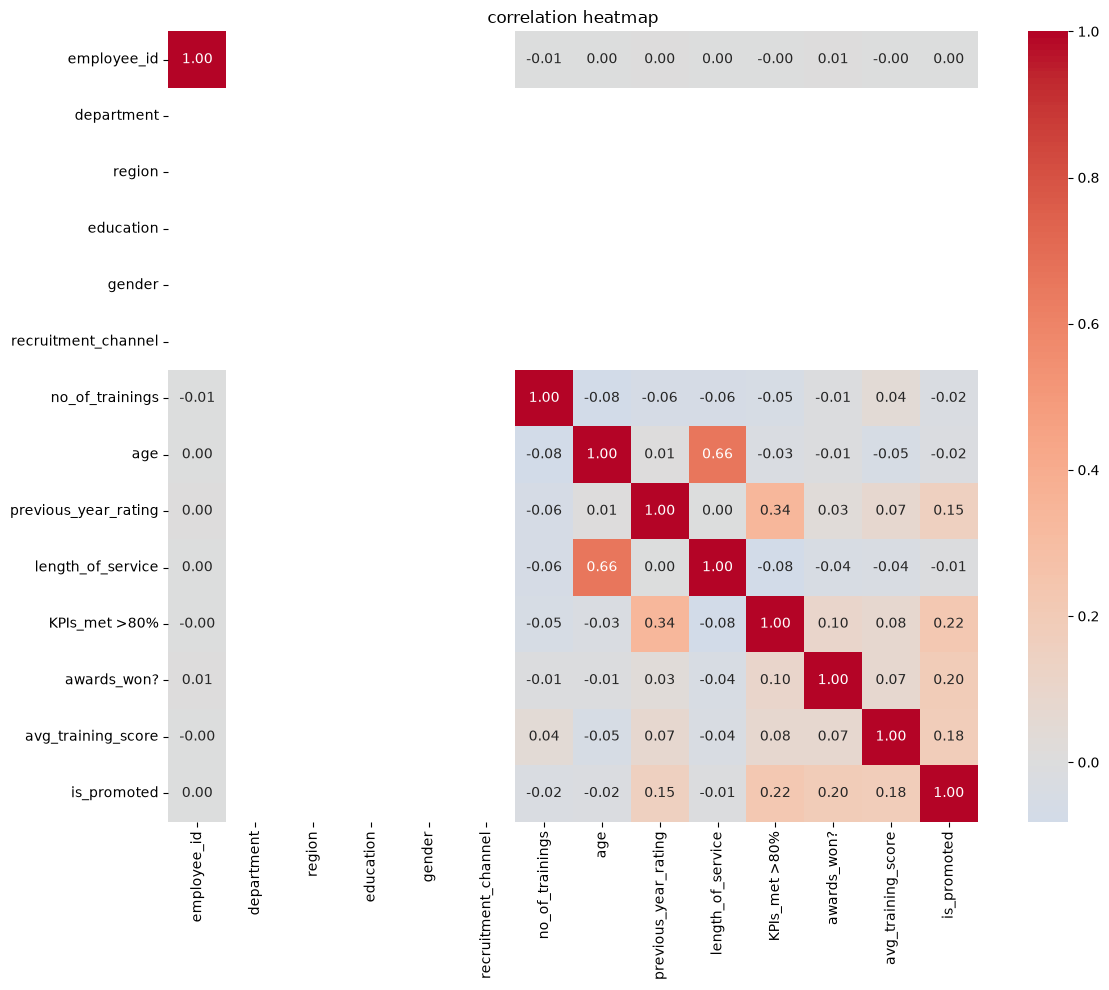

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("correlation heatmap");plt.tight_layout();plt.show()
